In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy

In [2]:
def plot_sampled_regression_models(betas, k, N):
    x = np.linspace(-1, 1, 10000)
    y = np.zeros((N, x.shape[0]))
    for h in range(N):
        for i in range(x.shape[0]):
            for j in range(k):
                y[h, i] = y[h, i] + betas[h, j]*x[i]**j
    fig, ax = plt.subplots()
    for i in range(N):
        formula = ""
        for j in range(k):
            plus = ""
            x_power = ""
            if j != 0:
                x_power = f"x^{j}"
            if j != k-1:
                plus = "+" if betas[i,j] >= 0 else ""
            formula = f"{plus}{betas[i,j]:.2f}{x_power}" + formula
        ax.plot(x, y[i], label=f"$y = {formula}$")
    ax.legend(bbox_to_anchor=(-0.1, 1), loc='upper right', fontsize = 12)
    ax.set_title("sampling beta", fontsize=18)
    ax.set_xlim([-1, 1])
    ax.tick_params(labelsize=12)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.grid(True)
    plt.show()

In [3]:
def plot_a_sampled_regression_model_with_y(beta, lam, n=30):
    k = beta.shape[0]
    x = np.linspace(-1, 1, n)
    y = np.zeros(n)
    for i in range(n):
        x_power = np.zeros(k)
        for j in range(k):
            x_power[j] = x[i]**j
        ave = beta @ x_power
        pre = 1 / lam
        y_sample = scipy.stats.multivariate_normal.rvs(ave, pre, 1)
        y[i] = y_sample
    n_reg = 10000
    x_reg = np.linspace(-1, 1, n_reg)
    y_reg = np.zeros(x_reg.shape[0])
    for i in range(n_reg):
        x_power = np.zeros(k)
        for j in range(k):
            x_power[j] = x_reg[i]**j
        y_reg[i] = beta @ x_power
    fig, ax = plt.subplots()
    ax.scatter(x, y, color="black")
    ax.plot(x_reg, y_reg)
    ax.set_xlim([-1, 1])
    ax.grid(True)
    plt.show()

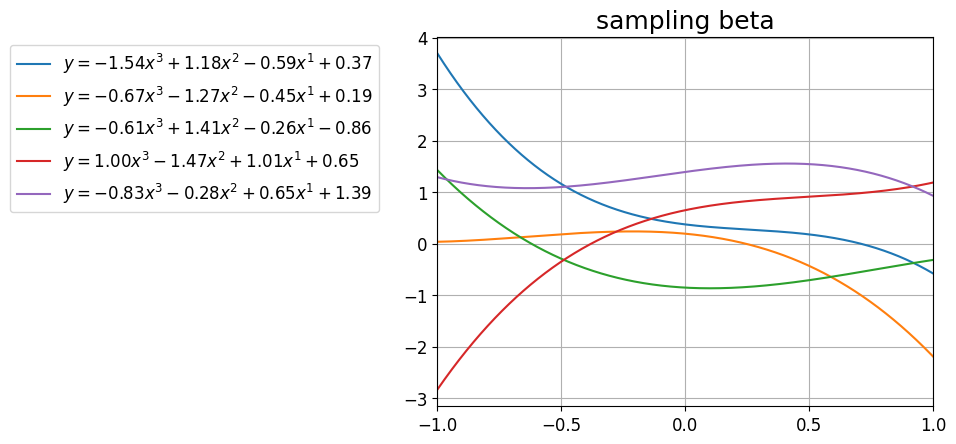

In [4]:
k = 4
loc = np.zeros(k)
scale = np.eye(k)
N = 5
betas = scipy.stats.multivariate_normal.rvs(loc, scale, N)
plot_sampled_regression_models(betas, k, N)


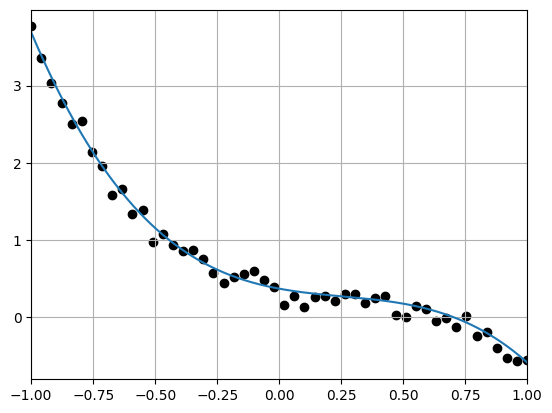

In [5]:
beta = betas[0]
lam = 100
n = 50
plot_a_sampled_regression_model_with_y(beta, lam, n)